# Rachelle LIU：Salary Analysis by Position Level

## Research question
How do advertised monthly salary ranges differ across position levels in Singapore IT job postings?

Use the latest team cleaning rules: valid Monthly salaries, peer-group IQR, and additional thresholds B. Read all records from `jobs_clean.csv`, then select **salary_analysis_ready=True**. Keep False records only for the cleaning audit. Never use the group median benchmark to replace salary values.

The main measure is the **advertised salary midpoint**, not actual employee pay. The median describes the middle posting; Q1–Q3 describes the middle 50% of posting midpoints.

In [1]:
# STEP 1: Load the latest team output and select analysis-ready records.
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("outputs/rl_salary_analysis")
output_dir.mkdir(parents=True, exist_ok=True)
all_jobs = pd.read_csv("jobs_clean.csv", low_memory=False)
required_columns = [
    "metadata_jobPostId", "position_level", "it_job_category",
    "salary_minimum", "salary_maximum", "salary_midpoint", "salary_band_width",
    "salary_analysis_ready", "salary_valid", "salary_classification",
    "salary_threshold_review_flag"
]
missing_columns = [c for c in required_columns if c not in all_jobs]
assert not missing_columns, f"Missing columns: {missing_columns}"
assert all_jobs["salary_analysis_ready"].notna().all()
assert all_jobs["salary_analysis_ready"].isin([True, False]).all()
salary = all_jobs.loc[all_jobs["salary_analysis_ready"].eq(True)].copy()
assert not salary.empty
assert salary["metadata_jobPostId"].notna().all()
assert salary["metadata_jobPostId"].is_unique
assert salary["salary_valid"].all()
assert salary["salary_classification"].eq("Within range").all()
assert not salary["salary_threshold_review_flag"].any()
# Confirm the dedicated analysis export contains the same postings.
analysis_ids = pd.read_csv("salary_analysis.csv", usecols=["metadata_jobPostId"])
assert set(salary["metadata_jobPostId"]) == set(analysis_ids["metadata_jobPostId"])
print(f"All IT study records: {len(all_jobs):,}")
print(f"Excluded for review: {len(all_jobs) - len(salary):,}")
print(f"Analysis-ready records: {len(salary):,}")
display(salary[required_columns].head())

All IT study records: 140,866
Excluded for review: 6,363
Analysis-ready records: 134,503


,metadata_jobPostId,position_level,it_job_category,salary_minimum,salary_maximum,salary_midpoint,salary_band_width,salary_analysis_ready,salary_valid,salary_classification,salary_threshold_review_flag
0,MCF-2023-0273977,Executive,Software & Application Development,4000,5500,4750.0,1500,True,True,Within range,False
1,MCF-2023-0273991,Senior Executive,Software & Application Development,5000,10000,7500.0,5000,True,True,Within range,False
2,MCF-2023-0273974,Junior Executive,Software & Application Development,4000,6000,5000.0,2000,True,True,Within range,False
3,MCF-2023-0273984,Manager,Other IT,8000,10000,9000.0,2000,True,True,Within range,False
4,MCF-2023-0261993,Non-executive,Other IT,3000,4800,3900.0,1800,True,True,Within range,False


## Step 2: Verify the sample and inspect the effect of cleaning

Report missing fields explicitly. Show retained and excluded counts by position level because filtering may affect levels differently. These are posting counts, not numbers of employees or vacancies.

In [2]:
analysis_check = pd.DataFrame({
    "data_type": salary[required_columns].dtypes,
    "missing_count": salary[required_columns].isna().sum(),
    "unique_values": salary[required_columns].nunique()
})
display(analysis_check)
assert salary[["position_level", "it_job_category", "salary_midpoint"]].notna().all().all()
retention_by_level = all_jobs.groupby("position_level", dropna=False).agg(
    original_postings=("metadata_jobPostId", "size"),
    retained_postings=("salary_analysis_ready", "sum")
)
retention_by_level["excluded_postings"] = retention_by_level["original_postings"] - retention_by_level["retained_postings"]
retention_by_level["excluded_percent"] = 100 * retention_by_level["excluded_postings"] / retention_by_level["original_postings"]
display(retention_by_level.round(2))

,data_type,missing_count,unique_values
metadata_jobPostId,object,0,134503
position_level,object,0,9
it_job_category,object,0,7
salary_minimum,int64,0,466
salary_maximum,int64,0,583
salary_midpoint,float64,0,870
salary_band_width,int64,0,501
salary_analysis_ready,bool,0,1
salary_valid,bool,0,1
salary_classification,object,0,1


,original_postings,retained_postings,excluded_postings,excluded_percent
position_level,,,,
Executive,36485,35354,1131,3.10
Fresh/entry level,6204,5546,658,10.61
Junior Executive,15755,15547,208,1.32
Manager,12643,12080,563,4.45
Middle Management,4127,3880,247,5.98
Non-executive,3968,3658,310,7.81
Professional,36272,33814,2458,6.78
Senior Executive,22564,22035,529,2.34
Senior Management,2848,2589,259,9.09


## Step 3: Compare median midpoint and the middle 50% range

Keep the mean as a secondary measure. `q1_midpoint` and `q3_midpoint` describe the distribution across postings. `median_advertised_minimum` and `median_advertised_maximum` summarise the advertised endpoints separately; they are not Q1 and Q3. These summaries are calculated after selection, while the cleaning IQR benchmarks remain unchanged.

In [3]:
salary_by_level = salary.groupby("position_level").agg(
    posting_count=("metadata_jobPostId", "nunique"),
    median_midpoint=("salary_midpoint", "median"),
    mean_midpoint=("salary_midpoint", "mean"),
    q1_midpoint=("salary_midpoint", lambda v: v.quantile(0.25)),
    q3_midpoint=("salary_midpoint", lambda v: v.quantile(0.75)),
    median_advertised_minimum=("salary_minimum", "median"),
    median_advertised_maximum=("salary_maximum", "median"),
    median_band_width=("salary_band_width", "median")
).sort_values("median_midpoint", ascending=False)
salary_by_level["posting_share_percent"] = salary_by_level["posting_count"] / len(salary) * 100
assert salary_by_level["posting_count"].sum() == len(salary)
print(f"Overall median midpoint: SGD {salary['salary_midpoint'].median():,.2f}")
print(f"Overall mean midpoint: SGD {salary['salary_midpoint'].mean():,.2f}")
display(salary_by_level.round(2))

Overall median midpoint: SGD 6,500.00
Overall mean midpoint: SGD 6,598.63


,posting_count,median_midpoint,mean_midpoint,q1_midpoint,q3_midpoint,median_advertised_minimum,median_advertised_maximum,median_band_width,posting_share_percent
position_level,,,,,,,,,
Senior Management,2589,11500.0,12089.91,9200.0,14500.0,10000.0,13000.0,4000.0,1.92
Middle Management,3880,8750.0,9164.40,7000.0,10500.0,7000.0,10000.0,3000.0,2.88
Manager,12080,8000.0,8328.33,6500.0,10000.0,6600.0,9500.0,2500.0,8.98
Professional,33814,7887.5,8051.64,6250.0,9750.0,6000.0,9000.0,3000.0,25.14
Senior Executive,22035,7000.0,7157.54,5500.0,8750.0,5800.0,8500.0,2500.0,16.38
Executive,35354,5000.0,5257.02,3750.0,6500.0,4000.0,6000.0,1500.0,26.28
Junior Executive,15547,4000.0,4487.03,3250.0,5500.0,3500.0,5000.0,1500.0,11.56
Non-executive,3658,4000.0,4926.20,3000.0,6650.0,3200.0,5000.0,1500.0,2.72
Fresh/entry level,5546,2900.0,2967.73,2100.0,3791.0,2400.0,3500.0,900.0,4.12


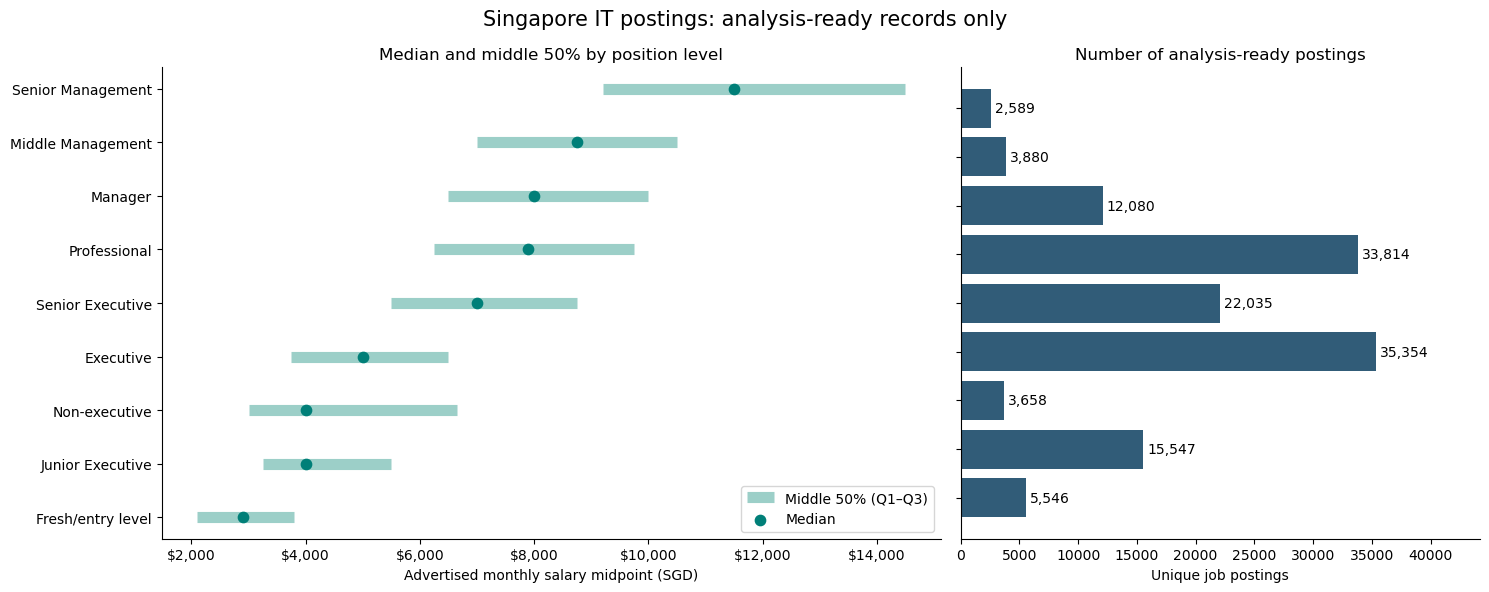

In [4]:
# STEP 4: Compare salary levels and sample sizes.
from matplotlib.ticker import StrMethodFormatter
chart_data = salary_by_level.sort_values("median_midpoint")
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.5, 1]})
y = range(len(chart_data))
axes[0].hlines(y, chart_data["q1_midpoint"], chart_data["q3_midpoint"], color="#9CCFC8", linewidth=8, label="Middle 50% (Q1–Q3)")
axes[0].scatter(chart_data["median_midpoint"], y, color="#007F78", s=55, zorder=3, label="Median")
axes[0].set_yticks(list(y), chart_data.index)
axes[0].set_xlabel("Advertised monthly salary midpoint (SGD)")
axes[0].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
axes[0].set_title("Median and middle 50% by position level")
axes[0].legend(loc="lower right")
axes[1].barh(list(y), chart_data["posting_count"], color="#315C78")
axes[1].set_yticks(list(y), [])
axes[1].set_xlim(0, chart_data["posting_count"].max() * 1.25)
for i, count in enumerate(chart_data["posting_count"]):
    axes[1].text(count + 350, i, f"{count:,}", va="center")
axes[1].set_xlabel("Unique job postings")
axes[1].set_title("Number of analysis-ready postings")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Singapore IT postings: analysis-ready records only", fontsize=15)
fig.tight_layout()
fig.savefig(output_dir / "salary_by_position_level.png", dpi=200, bbox_inches="tight")
plt.show()

## Step 5: Compare within IT job categories

An overall level comparison mixes different job functions. Use this category-by-level table to inspect that mix. Small selected groups remain visible in the counts table; hide medians with fewer than five selected records in the comparison table. `Other IT` is a broad title-based category, so its jobs may still differ substantially.

In [5]:
salary_by_category_level = salary.groupby(["it_job_category", "position_level"]).agg(
    posting_count=("metadata_jobPostId", "nunique"),
    median_midpoint=("salary_midpoint", "median"),
    q1_midpoint=("salary_midpoint", lambda v: v.quantile(0.25)),
    q3_midpoint=("salary_midpoint", lambda v: v.quantile(0.75))
)
category_medians = salary_by_category_level["median_midpoint"].where(
    salary_by_category_level["posting_count"].ge(5)
).unstack("position_level").reindex(columns=salary_by_level.index)
category_counts = salary_by_category_level["posting_count"].unstack("position_level").reindex(columns=salary_by_level.index).fillna(0).astype(int)
display(category_medians.round(2))
display(category_counts)
print("Missing medians indicate fewer than five selected postings or no postings.")

position_level,Senior Management,Middle Management,Manager,Professional,Senior Executive,Executive,Junior Executive,Non-executive,Fresh/entry level
it_job_category,,,,,,,,,
Cybersecurity,14000.0,9250.0,8500.0,8000.0,7500.0,5250.0,4750.0,5925.0,3800.0
Data & Analytics,11500.0,9500.0,9000.0,8500.0,7500.0,6250.0,4750.0,7850.0,4625.0
IT Management & Business Systems,10000.0,9500.0,8250.0,8500.0,7500.0,6250.0,4500.0,6500.0,3000.0
IT Support & Systems,7925.0,7250.0,5750.0,5250.0,5000.0,3150.0,3150.0,3000.0,2700.0
Infrastructure & Cloud,11000.0,8000.0,8000.0,7500.0,6850.0,5250.0,4500.0,5500.0,3900.0
Other IT,12000.0,9000.0,8000.0,8000.0,6750.0,4050.0,3750.0,3500.0,2750.0
Software & Application Development,9000.0,7500.0,8000.0,7600.0,7500.0,6000.0,5250.0,7000.0,2000.0


position_level,Senior Management,Middle Management,Manager,Professional,Senior Executive,Executive,Junior Executive,Non-executive,Fresh/entry level
it_job_category,,,,,,,,,
Cybersecurity,132,172,436,1087,958,1446,339,84,99
Data & Analytics,57,151,312,1795,701,913,284,83,156
IT Management & Business Systems,229,437,2509,3119,2327,2222,517,157,190
IT Support & Systems,16,54,121,983,572,3044,1454,437,423
Infrastructure & Cloud,249,377,1110,4444,3286,5050,1708,408,580
Other IT,1705,1958,6712,13905,8287,14676,8404,1816,3003
Software & Application Development,201,731,880,8481,5904,8003,2841,673,1095


Missing medians indicate fewer than five selected postings or no postings.


## Step 6: Findings and exports

The following findings are generated from the current data. Differences are descriptive: job function mix, experience and posting dates can also affect salary. Advertisements may cover similar roles at different employers, so each posting is not a unique worker. Filtering describes typical advertised salaries and deliberately excludes some legitimate unusual offers.

In [6]:
highest = salary_by_level.iloc[0]
lowest = salary_by_level.iloc[-1]
most_postings = salary_by_level["posting_count"].idxmax()
findings = [
    f"Analysis uses {len(salary):,} of {len(all_jobs):,} IT postings; {len(all_jobs)-len(salary):,} remain excluded for review.",
    f"The overall median advertised monthly midpoint is SGD {salary['salary_midpoint'].median():,.2f}.",
    f"{salary_by_level.index[0]} has the highest median, SGD {highest['median_midpoint']:,.2f}, with {int(highest['posting_count']):,} postings.",
    f"{salary_by_level.index[-1]} has the lowest median, SGD {lowest['median_midpoint']:,.2f}, with {int(lowest['posting_count']):,} postings.",
    f"The highest-to-lowest median ratio is {highest['median_midpoint']/lowest['median_midpoint']:.2f}; this is not a causal estimate of the return to seniority.",
    f"{most_postings} has the most postings ({int(salary_by_level.loc[most_postings, 'posting_count']):,}).",
    "Compare categories as well as levels; overlapping Q1–Q3 ranges show that salary is not determined by position level alone.",
]
for finding in findings:
    print("-", finding)
report = "# Salary analysis by position level\n\n" + "\n".join("- " + f for f in findings)
report += "\n\nOnly salary_analysis_ready=True records are used. Midpoints describe advertised ranges, not actual employee pay.\n"
(output_dir / "Findings.md").write_text(report)
salary_by_level.to_csv(output_dir / "salary_by_position_level.csv")
salary_by_category_level.to_csv(output_dir / "salary_by_category_and_level.csv")
retention_by_level.to_csv(output_dir / "retention_by_position_level.csv")
print("Saved analysis tables, chart and findings to", output_dir)

- Analysis uses 134,503 of 140,866 IT postings; 6,363 remain excluded for review.
- The overall median advertised monthly midpoint is SGD 6,500.00.
- Senior Management has the highest median, SGD 11,500.00, with 2,589 postings.
- Fresh/entry level has the lowest median, SGD 2,900.00, with 5,546 postings.
- The highest-to-lowest median ratio is 3.97; this is not a causal estimate of the return to seniority.
- Executive has the most postings (35,354).
- Compare categories as well as levels; overlapping Q1–Q3 ranges show that salary is not determined by position level alone.
Saved analysis tables, chart and findings to outputs/rl_salary_analysis
